In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df=pd.read_csv("smartcart_customers.csv")

In [63]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,42,118,247,2,9,3,4,5,0,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,0,0,8,7,8,2,5,7,0,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,32,12,24,1,2,3,13,6,0,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,80,30,61,2,6,5,10,3,0,0


In [64]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Data Preprocessing

# 1.Handle Missing value 

In [65]:
df["Incomes"] = df["Income"].fillna(df["Income"].median())

In [66]:
df.shape

(2240, 23)

In [67]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
Incomes                 0
dtype: int64

In [68]:
df.shape

(2240, 23)

# 2.Features Enginearing

In [69]:
# Age

df["Age"] = 2026 - df["Year_Birth"]

In [70]:
df


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Incomes,Age
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,88,3,8,10,4,7,0,1,58138.0,69
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,6,2,1,1,2,5,0,0,46344.0,72
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,42,1,8,2,10,4,0,0,71613.0,61
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,5,2,2,0,4,6,0,0,26646.0,42
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,15,5,5,3,6,5,0,0,58293.0,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,247,2,9,3,4,5,0,0,61223.0,59
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,8,7,8,2,5,7,0,0,64014.0,80
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,24,1,2,3,13,6,0,0,56981.0,45
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,61,2,6,5,10,3,0,0,69245.0,70


In [71]:
# Customer joing date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure"]=(reference_date - df["Dt_Customer"]).dt.days

In [72]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Incomes,Age,Customer_Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,58138.0,69,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,46344.0,72,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,71613.0,61,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,26646.0,42,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,58293.0,45,161


In [73]:
# Purchase
df["Total_Spending"]= df["MntWines"] +  df["MntMeatProducts"] + df["MntFruits"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]  

In [74]:
df.columns


Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Incomes', 'Age', 'Customer_Tenure',
       'Total_Spending'],
      dtype='object')

In [75]:
# Children
df["Total_Children"] = df["Kidhome"]+df["Teenhome"]

In [76]:
# Education :- 

# Undergraduate , Graduate , Postgradutae
df["Education"]=df["Education"].replace({
    "Basic":"Undergraduate","2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master":"Postgraduate" , "PhD":"Postgraduate"
})

In [77]:
df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [78]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Incomes,Age,Customer_Tenure,Total_Spending,Total_Children
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,58138.0,69,663,1617,0
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,46344.0,72,113,27,2
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,71613.0,61,312,776,0
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,26646.0,42,139,53,1
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,58293.0,45,161,422,1


In [79]:
# Marital Status 
df["Living_With"]=df["Marital_Status"].replace({
    "Married":"Partner","Together":"Partner",
    "Single":"Alone","Divorced":"Alone",
    "Widow":"Alone" , "Absurd":"Alone","YOLO":"Alone"
})

In [80]:
df["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

In [81]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Incomes', 'Age', 'Customer_Tenure',
       'Total_Spending', 'Total_Children', 'Living_With'],
      dtype='object')

In [82]:
# Remove unused columns in the future
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer","Income"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols+spending_cols

df_cleaned = df.drop(columns=cols_to_drop)


In [83]:
df_cleaned.shape

(2240, 15)

In [84]:
df_cleaned.head()

,Education,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Incomes,Age,Customer_Tenure,Total_Spending,Total_Children,Living_With
0,Graduate,58,3,8,10,4,7,0,1,58138.0,69,663,1617,0,Alone
1,Graduate,38,2,1,1,2,5,0,0,46344.0,72,113,27,2,Alone
2,Graduate,26,1,8,2,10,4,0,0,71613.0,61,312,776,0,Partner
3,Graduate,26,2,2,0,4,6,0,0,26646.0,42,139,53,1,Partner
4,Postgraduate,94,5,5,3,6,5,0,0,58293.0,45,161,422,1,Partner


# Outliers

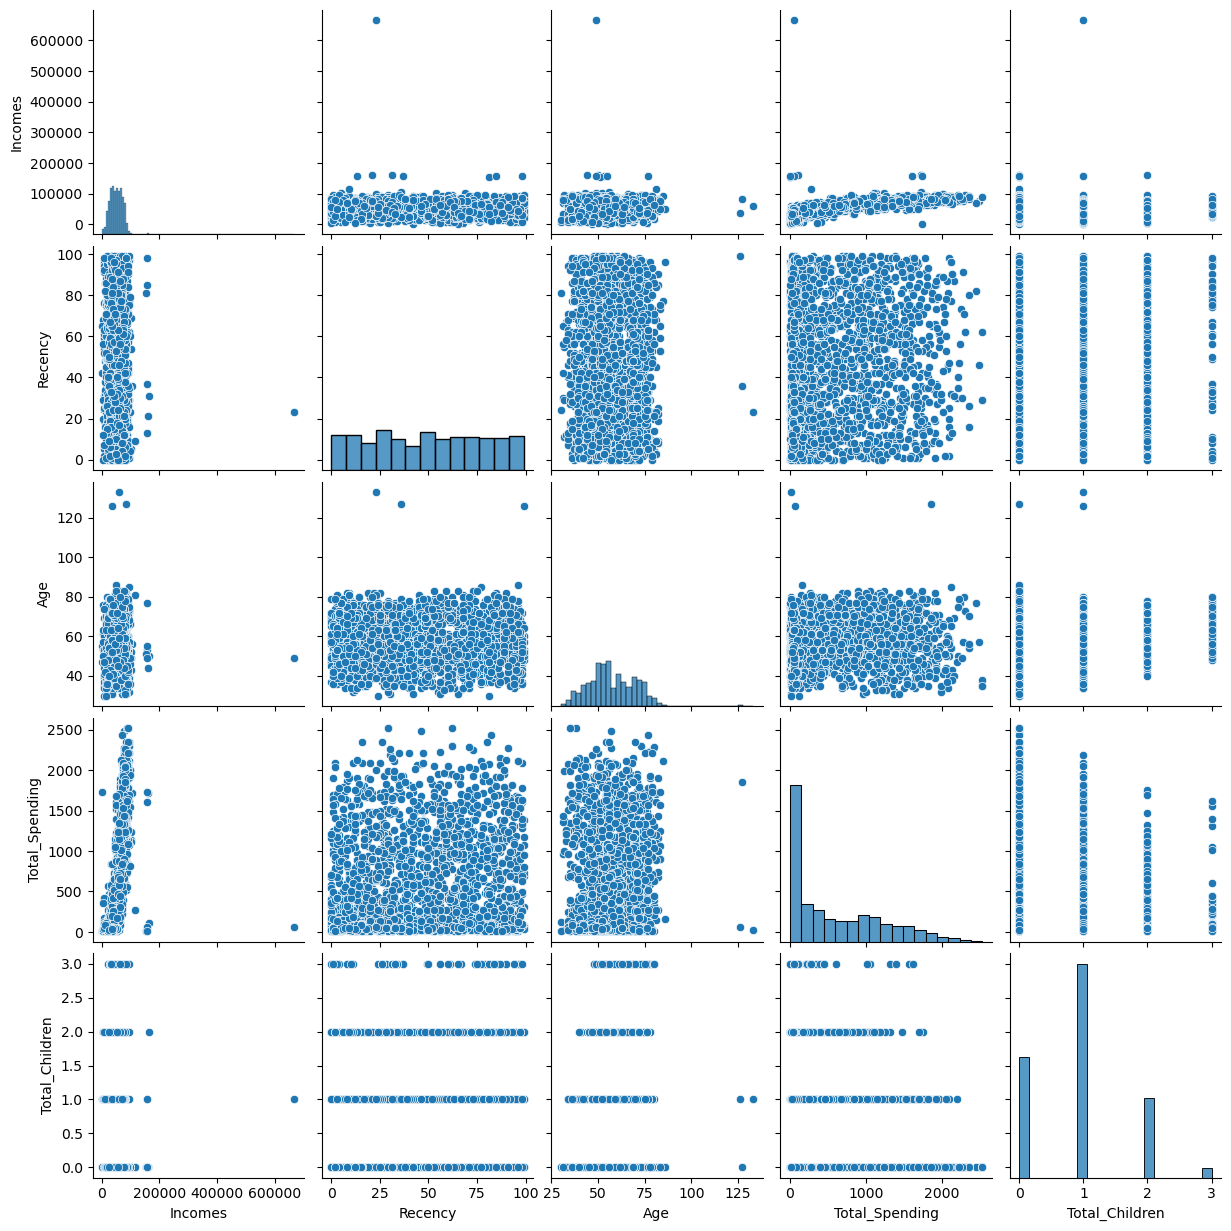

In [85]:
cols = ["Incomes" , "Recency", "Age" , "Total_Spending","Total_Children"]

# relative plots of some features -pair plots
sns.pairplot(df_cleaned[cols])

In [88]:
# Remove outliers

print("data size with outliers:", len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[(df_cleaned["Incomes"]<600_000)]

print("data size without outliers" , len(df_cleaned))

data size with outliers: 2240
data size without outliers 2236


# HeatMap

In [89]:
corr = df_cleaned.corr(numeric_only=True)


,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Incomes,Age,Customer_Tenure,Total_Spending,Total_Children
Recency,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.007829,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,-0.107169,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.450584,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.693781,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.628075,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.646382,-0.117498,0.272105,-0.499909,0.417908
Complain,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,-0.027871,0.004450,0.035685,-0.033784,0.031480
Response,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,0.161121,-0.018557,0.194232,0.265615,-0.169451
Incomes,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,1.000000,0.198835,-0.023677,0.789375,-0.340550
Age,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,0.198835,1.000000,-0.016451,0.113618,0.095512


<Axes: >

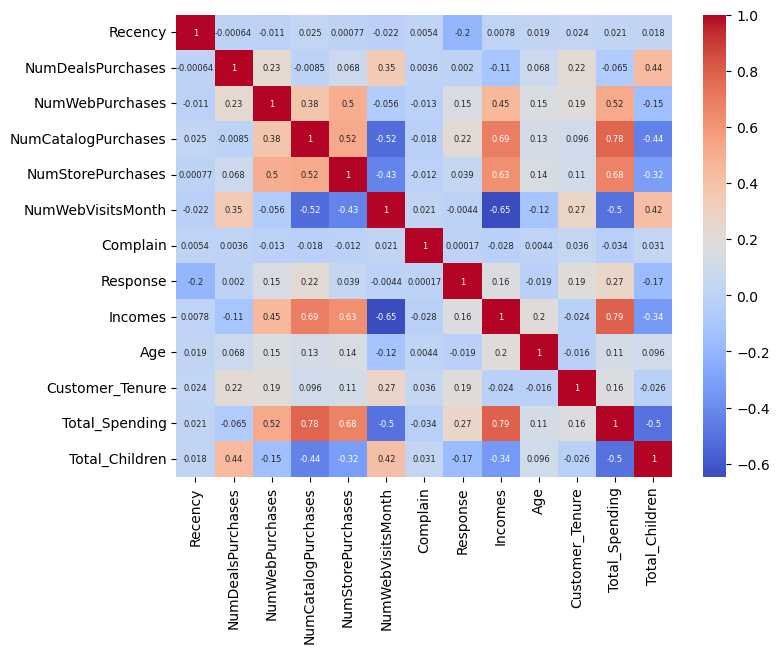

In [91]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

In [93]:
df.shape


(2240, 28)

In [95]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Incomes,Age,Customer_Tenure,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,4,7,0,1,58138.0,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,2,5,0,0,46344.0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,10,4,0,0,71613.0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,4,6,0,0,26646.0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,6,5,0,0,58293.0,45,161,422,1,Partner


# Features Encoding 


In [96]:
from sklearn.preprocessing import OneHotEncoder

In [97]:
ohe = OneHotEncoder()

cat_cols=["Education" , "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [99]:
enc_df = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index=df_cleaned.index)

In [100]:
enc_df

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
2235,1.0,0.0,0.0,0.0,1.0
2236,0.0,1.0,0.0,0.0,1.0
2237,1.0,0.0,0.0,1.0,0.0
2238,0.0,1.0,0.0,0.0,1.0


In [104]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_cols),enc_df],axis =1)

In [105]:
df_encoded.shape

(2236, 18)

In [106]:
df_encoded.head()

,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Incomes,Age,Customer_Tenure,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58,3,8,10,4,7,0,1,58138.0,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,38,2,1,1,2,5,0,0,46344.0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,26,1,8,2,10,4,0,0,71613.0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26,2,2,0,4,6,0,0,26646.0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,94,5,5,3,6,5,0,0,58293.0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


# Scaling

In [107]:
from sklearn.preprocessing import StandardScaler

In [108]:
X =df_encoded

In [109]:
scaler = StandardScaler()
X_scaled =scaler.fit_transform(X)

In [110]:
X_scaled

array([[ 0.30685572,  0.34873831,  1.4076389 , ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.38397129, -0.16869955, -1.11092123, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.7984675 , -0.68613742,  1.4076389 , ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 1.44672029, -0.68613742, -0.75112693, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-1.42021181, -0.16869955,  0.68805029, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [-0.31488859,  0.34873831, -0.39133262, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

# Visualize

In [111]:
X_scaled.shape

(2236, 18)

In [132]:
# 2D Visualistion
from sklearn.decomposition import PCA



In [133]:
# 3D for 2D PUT 2 n_component s
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

In [134]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

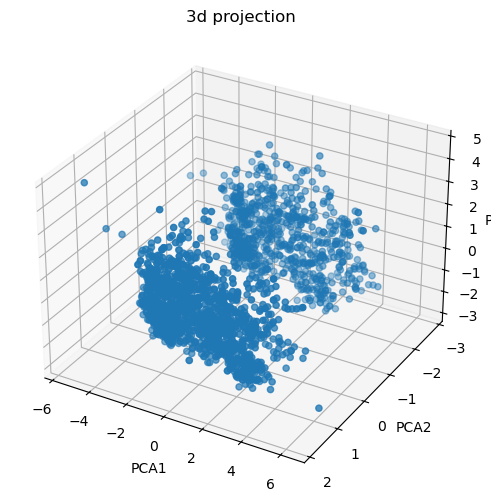

In [160]:
# plot
fig =  plt.figure(figsize=(8,6))
# Standard way to show 3D
ax = fig.add_subplot(111 , projection = "3d")

ax.scatter(X_pca[:, 0], X_pca[:,1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.invert_yaxis()
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

In [161]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

# Analyze K value
# 1.Elbow Method

In [162]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k , random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [163]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [164]:
print("Best k : " ,optimal_k)

Best k :  4


Text(0, 0.5, 'WCSS')

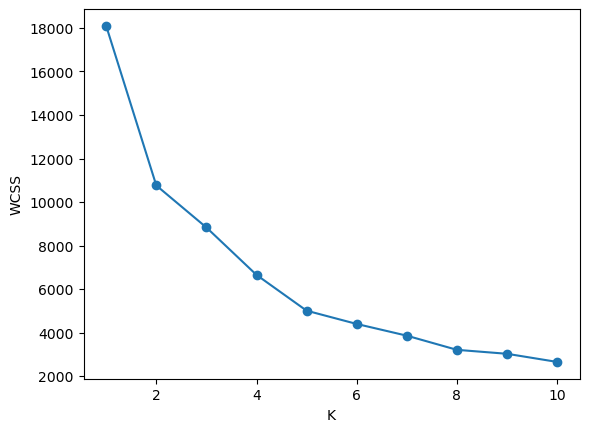

In [165]:
# Plot

plt.plot(range(1,11),wcss , marker = 'o')
plt.xlabel("K")
plt.ylabel("WCSS")

## 2.Silhoutee Score

Text(0, 0.5, 'Silhoutte score')

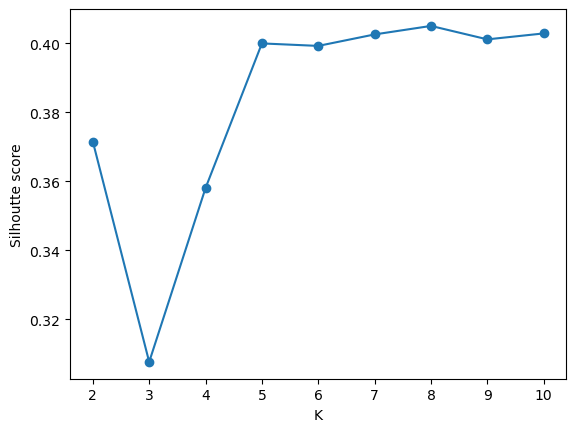

In [166]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)
# Plot
plt.plot(range(2,11) , scores , marker = 'o')
plt.xlabel("K")
plt.ylabel("Silhoutte score")    

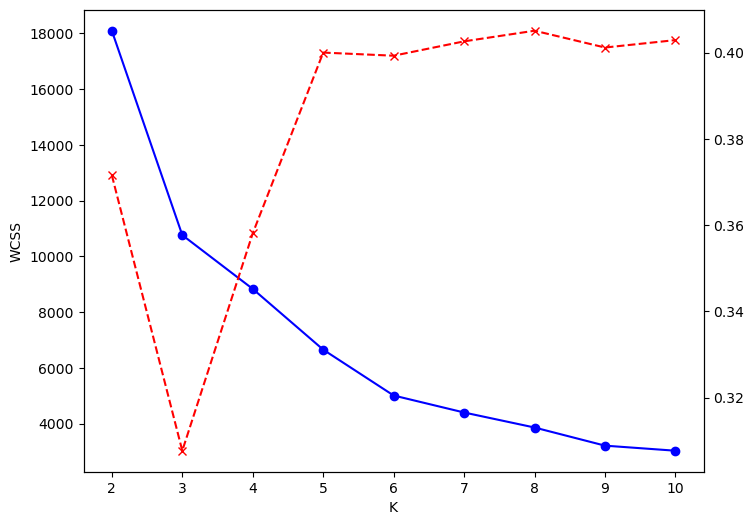

In [167]:
# Create a combine plot for bith the value
k_range = range(2,11)

fig,ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)],marker="x",color="red",linestyle="--")

# Clustring

In [168]:
# K-means

kmeans = KMeans(n_clusters=4,random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

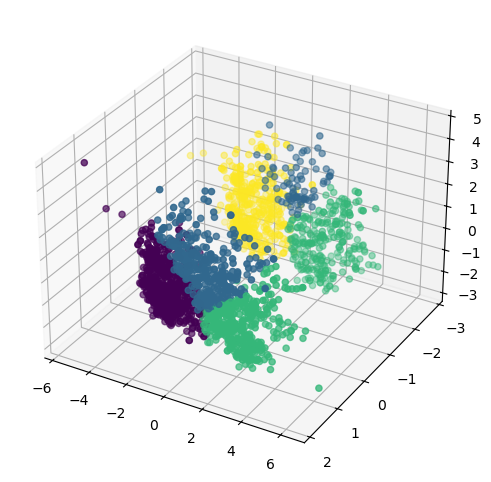

In [171]:
fig = plt.figure(figsize = (8,6))

ax = fig.add_subplot(111,projection = "3d")
ax.invert_yaxis()
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c = labels_kmeans)

In [175]:
# Agglomerative Clustring
from sklearn.cluster import AgglomerativeClustering

In [177]:
agg_clf = AgglomerativeClustering(n_clusters=4,linkage ="ward")
labels_agg = agg_clf.fit_predict(X_pca)

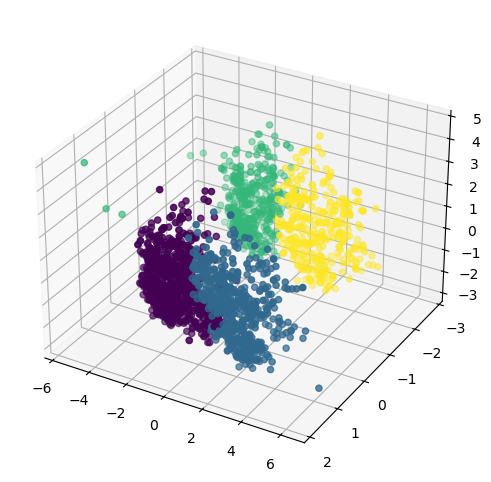

In [179]:
fig = plt.figure(figsize = (8,6))

ax = fig.add_subplot(111,projection = "3d")
ax.invert_yaxis()
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c = labels_agg)

# Characterization of Clusters

In [186]:

X["cluster"] = labels_agg


In [187]:
X.head()

,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Incomes,Age,Customer_Tenure,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58,3,8,10,4,7,0,1,58138.0,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,38,2,1,1,2,5,0,0,46344.0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,26,1,8,2,10,4,0,0,71613.0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26,2,2,0,4,6,0,0,26646.0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,94,5,5,3,6,5,0,0,58293.0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

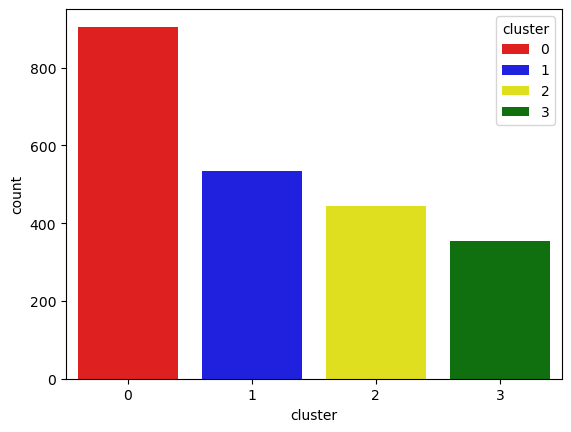

In [188]:
pal = ["red","blue","yellow","green"]

sns.countplot(x=X["cluster"],palette=pal,hue = X["cluster"])

<Axes: xlabel='Total_Spending', ylabel='Incomes'>

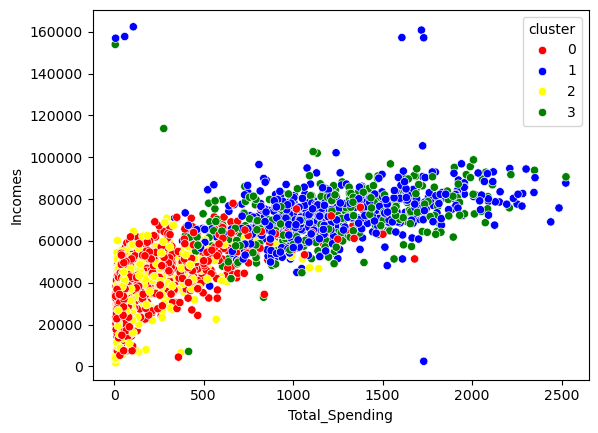

In [190]:
# Income and Spending pattern

sns.scatterplot(x=X["Total_Spending"], y=X["Incomes"],hue = X["cluster"],palette=pal)

# Cluster Summary

In [192]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

           Recency  NumDealsPurchases  NumWebPurchases  NumCatalogPurchases  \
cluster                                                                       
0        48.914917           2.594475         3.153591             0.969061   
1        49.202247           1.958801         5.687266             5.498127   
2        48.319820           2.594595         2.713964             0.837838   
3        50.504249           1.855524         5.790368             5.014164   

         NumStorePurchases  NumWebVisitsMonth  Complain  Response  \
cluster                                                             
0                 4.143646           6.307182  0.011050  0.076243   
1                 8.659176           3.580524  0.005618  0.166667   
2                 3.623874           6.659910  0.011261  0.141892   
3                 8.430595           3.728045  0.005666  0.320113   

              Incomes        Age  Customer_Tenure  Total_Spending  \
cluster                                  